# CNN sur le Cifar10 dataset.

### <font color='blue'>Importer les libraries et initialser une carte graphique (GPU) </font>

In [1]:
# Importer les libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt

from pytorch_utils import train_net, evaluate, plot_training_history, model_predict

### <font color='blue'> Charger et explorer le jeu de données. Choisir un nombre limité de données pour l'entrainement. </font>

In [ ]:
# Chargement via torchvision (équivalent de tf.keras.datasets.cifar10): 
# Pour comprendre plus sur ces données veillez visiter ce lien: https://www.cs.toronto.edu/~kriz/cifar.html
from torch.utils.data import Subset
from torchvision import datasets
import torchvision.transforms as T

mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std),
])
test_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

# Pour plus de details sur l'operation de normalisation, voir: https://docs.pytorch.org/vision/stable/generated/torchvision.transforms.v2.Normalize.html#torchvision.transforms.v2.Normalize

train_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf)
val_full = datasets.CIFAR10(root='./data', train=True, transform=test_tf)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

# Chacune des sets, en plus des images, contient aussi les étiquettes
print(f'Train images shape : {train_full.data.shape}')
print(f'Train labels shape : {len(train_full.targets)}') # Une liste

print(f'Test images shape : {test_set.data.shape}')
print(f'Test labels shape : {len(test_set.targets)}') # Une liste

  3%|███▌                                                                                                       | 5.73M/170M [01:41<1:31:03, 30.2kB/s]

In [ ]:

# Splitter le validation set
num_train = 45000
g = torch.Generator().manual_seed(0)
idx = torch.randperm(len(train_full), generator=g)
train_set = Subset(train_full, idx[:num_train])
val_set   = Subset(val_full,   idx[num_train:])

In [ ]:
# Explorer le jeu de donnée
index_img = 506
plt.imshow(train_full.data[index_img,:,:])
plt.title('Ceci est l\'image de: '+str(train_full.targets[index_img]))

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# Hyperparametres
nombre_epochs =400
batch_size = 64
lr = 0.001

### <font color='blue'> Definir un CNN

In [ ]:
#conv block
def conv_block(c_in, c_out, max_pool_flag=True):
    """3x3 convolution -> Batch Normalization -> ReLU, optionally followed by
    2x2 max pooling (halves resolution)."""
    layers = [
        nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(c_out),
        nn.ReLU(inplace=True),
    ]
    if max_pool_flag:
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
    return nn.Sequential(*layers)

In [ ]:
# premier modèle CNN
# Definir le model
class CNN_MODEL(nn.Module):
    def __init__(self,
                 in_channels: int = 1,
                 input_size: tuple = (28, 28),
                 hidden_dims=[32, 16],
                 num_classes: int = 10,
                 dropout = 0.2) -> None:
        super().__init__()

        self.feature_extractor = nn.Sequential(
            conv_block(3, 16),     # 32x32 -> 16x16
            conv_block(16, 32),    # 16x16 -> 8x8
            conv_block(32, 48),    # 8x8   -> 4x4
            conv_block(48, 48, max_pool_flag=False), # 4x4 -> 4x4
            nn.AdaptiveAvgPool2d((1, 1)),  # 4x4 -> 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(48, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.feature_extractor(x))


In [ ]:
# Verifier le model
model_cnn = CNN_MODEL(3, (32, 32))
print(model_cnn)

n_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {n_params:,}')

In [35]:
# Extraire une couche du modèle
layer1 = model_cnn.feature_extractor[0]
print(layer1)
print("---------------------")
print(layer1[0])

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
---------------------
Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


### <font color='blue'> Entrainer et evaluer le modèle </font>

In [36]:
# Entrainement du modèle
# Entrainer le modèle
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=3, persistent_workers=True, prefetch_factor=4)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=3, persistent_workers=True, prefetch_factor=4)

optimizer = torch.optim.AdamW(model_cnn.parameters(), lr=lr, weight_decay=1e-6)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=50, min_lr=1e-5)

cnn_trained, history_cnn = train_net(model_cnn, train_loader, val_loader, nombre_epochs, optimizer, criterion, scheduler)

Using mps device
Epoch   1/400  loss=1.5027  acc=0.4516  val_loss=1.3795  val_acc=0.5036  LR=1.00e-03
Epoch   2/400  loss=1.1880  acc=0.5760  val_loss=1.1655  val_acc=0.5912  LR=1.00e-03
Epoch   3/400  loss=1.0767  acc=0.6185  val_loss=1.0535  val_acc=0.6144  LR=1.00e-03
Epoch   4/400  loss=1.0079  acc=0.6422  val_loss=0.9386  val_acc=0.6636  LR=1.00e-03
Epoch   5/400  loss=0.9504  acc=0.6668  val_loss=0.9293  val_acc=0.6720  LR=1.00e-03
Epoch   6/400  loss=0.9051  acc=0.6822  val_loss=0.8382  val_acc=0.7068  LR=1.00e-03
Epoch   7/400  loss=0.8777  acc=0.6921  val_loss=0.8102  val_acc=0.7190  LR=1.00e-03
Epoch   8/400  loss=0.8510  acc=0.7019  val_loss=0.8294  val_acc=0.7092  LR=1.00e-03
Epoch   9/400  loss=0.8251  acc=0.7114  val_loss=0.8907  val_acc=0.6934  LR=1.00e-03
Epoch  10/400  loss=0.8110  acc=0.7159  val_loss=0.8104  val_acc=0.7176  LR=1.00e-03
Epoch  11/400  loss=0.7934  acc=0.7216  val_loss=0.7805  val_acc=0.7350  LR=1.00e-03
Epoch  12/400  loss=0.7771  acc=0.7295  val_loss

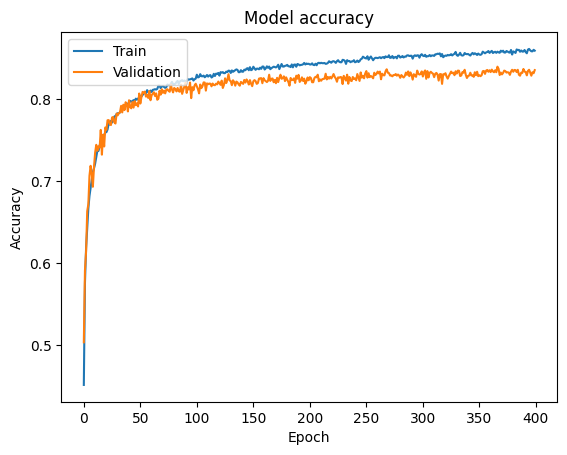

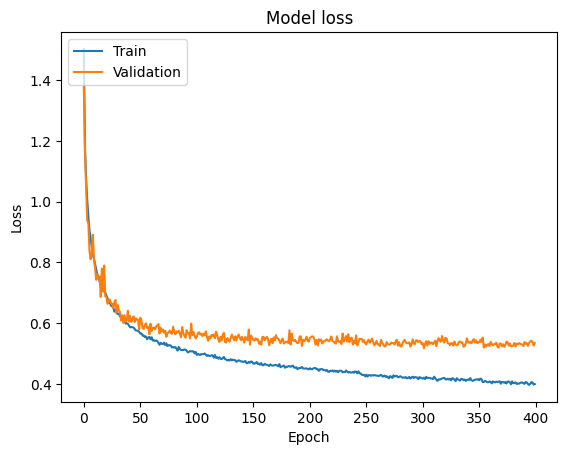

In [37]:
# Utiliser notre fonction plot_training_history pour afficher l'évolution de la fonction de coût
plot_training_history(history_cnn)

In [38]:
evaluate(cnn_trained, train_set)   # train réduit
evaluate(cnn_trained, train_full) # train complet
evaluate(cnn_trained, test_set)       # test

loss=0.3126  accuracy=0.8893
loss=0.3315  accuracy=0.8839
loss=0.5121  accuracy=0.8366


(0.5121034964084625, 0.8366)

In [ ]:
evaluate(cnn_v1_trained, train_set_reduit)   # train réduit
evaluate(cnn_v1_trained, train_full) # train complet
evaluate(cnn_v1_trained, test_set)       # test